In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
#from jax import vmap

In [3]:
cov_0 = np.array([[1, 0.8],
                  [0.8, 1]])

In [4]:
cov_1 = np.array([[1, -0.8],
                  [-0.8, 1]])

In [5]:
covs = np.array([cov_0, cov_1])

In [6]:
covs

array([[[ 1. ,  0.8],
        [ 0.8,  1. ]],

       [[ 1. , -0.8],
        [-0.8,  1. ]]])

In [7]:
np.array([np.linalg.cholesky(cov) for cov in covs])

array([[[ 1. ,  0. ],
        [ 0.8,  0.6]],

       [[ 1. ,  0. ],
        [-0.8,  0.6]]])

In [8]:
epss = np.random.standard_normal(4).reshape(2,2)

In [9]:
np.array([L @ eps for L, eps in zip(Ls, epss)])

NameError: name 'Ls' is not defined

In [ ]:
%%time
res = np.array([np.random.multivariate_normal(mean = [0, 0], cov = [[1, 0.8], [0.8, 1]]) for i in range(100_000)])

In [65]:
%%time
res = np.array([np.random.multivariate_normal(mean = [0], cov = [[2]]) for i in range(100_000)])

CPU times: user 1.85 s, sys: 20.8 ms, total: 1.88 s
Wall time: 1.85 s


In [67]:
%%time
res = np.array([np.array([np.random.normal(0, 2)]) for i in range(100_000)])

CPU times: user 90.4 ms, sys: 5.04 ms, total: 95.4 ms
Wall time: 94.6 ms


In [72]:
L = np.linalg.cholesky([[1,0.8], [0.8, 1]])

array([[1. , 0. ],
       [0.8, 0.6]])

In [180]:
%%time
res_0 = np.array([np.random.multivariate_normal(mean = [1, 2], cov = [[1, 0.8], [0.8, 1]]) for i in range(100_000)])

CPU times: user 1.97 s, sys: 11.7 ms, total: 1.99 s
Wall time: 1.98 s


In [2]:
%%time
Ls = np.array([np.linalg.cholesky([[1, 0.8], [0.8, 1]]) for i in range(100_000, 1)])
epss = np.random.standard_normal(200_000).reshape(100_000, 2)
res_1 = np.array( [L @ eps for Ls, eps in zip(Ls, epss)]) + np.tile(np.array([1, 2]), (100_000, 1))

ValueError: operands could not be broadcast together with shapes (0,) (100000,2) 

In [12]:
covs = jnp.array(np.tile([[1, 0.8, 0.8], [0.8, 1, 0.8], [0.8, 0.8, 1]], (100_000, 1,1)))
#covs.shape

In [13]:
#covs = np.array(np.tile([[1, 0.8], [0.8, 1]], (100_000, 1,1)))

In [14]:
%%time
Ls = jnp.linalg.cholesky(covs)
epss = np.random.standard_normal((100_000, 3))
res_2 = np.einsum('ijk,ik->ij', Ls, epss)

CPU times: user 71.2 ms, sys: 8.92 ms, total: 80.1 ms
Wall time: 56.5 ms


In [212]:
covs = jnp.array(np.tile([[1.0]], (100_000, 1,1)))
#covs.shape

In [211]:
covs

Array([[[1]],

       [[1]],

       [[1]],

       ...,

       [[1]],

       [[1]],

       [[1]]], dtype=int32)

In [213]:
%%time
Ls = jnp.linalg.cholesky(covs)
epss = np.random.standard_normal((100_000, 1))
res_2 = np.einsum('ijk,ik->ij', Ls, epss)

CPU times: user 50.6 ms, sys: 3.03 ms, total: 53.6 ms
Wall time: 35.6 ms


In [214]:
res_2.shape

(100000, 1)

In [224]:
%%time
res_2 = np.random.normal(np.array([0,1,2]), np.array([0,0,0]), 3)

CPU times: user 116 μs, sys: 3 μs, total: 119 μs
Wall time: 126 μs


In [225]:
res_2

array([0., 1., 2.])

In [194]:
res_2.shape

(100000, 3)

In [195]:
res_2[0]

array([0.94055332, 0.42285073, 0.61983869])

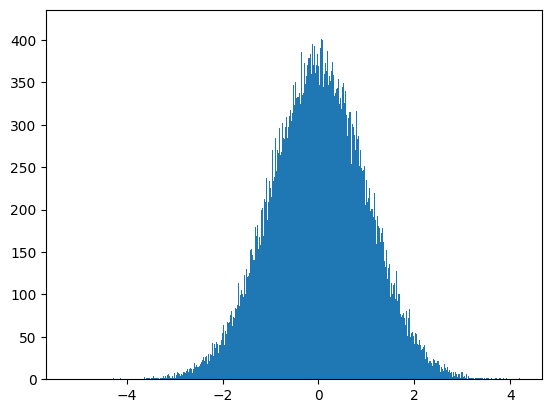

In [220]:
plt.hist(res_2[:,0], bins = 1000)
plt.show()

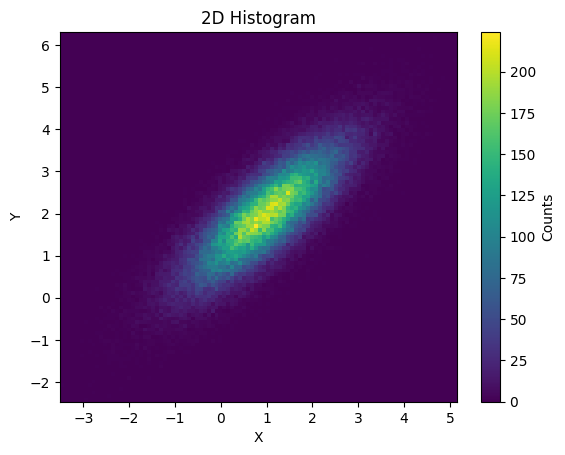

In [104]:
plt.hist2d(res_0[:,0], res_0[:,1], bins = 100, cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Histogram')
plt.show()


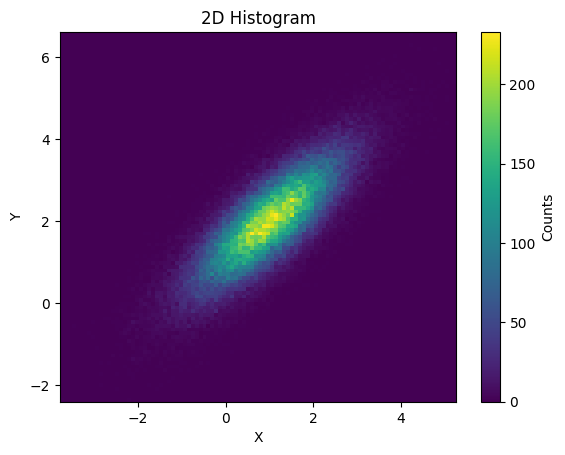

In [105]:
plt.hist2d(res_1[:,0], res_1[:,1], bins = 100, cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Histogram')
plt.show()

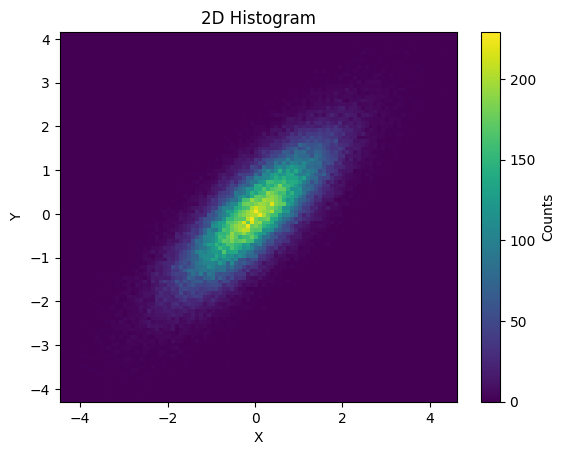

In [198]:
plt.hist2d(res_2[:,1], res_2[:,2], bins = 100, cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Histogram')
plt.show()

In [40]:
%%time
res = np.array([np.random.multivariate_normal(mean = [0, 0], cov = [[1, 0.8], [0.8, 1]]) for i in range(10000)])

CPU times: user 245 ms, sys: 16.5 ms, total: 262 ms
Wall time: 238 ms


In [40]:
%%time
res = np.array([np.random.multivariate_normal(mean = [0, 0], cov = [[1, 0.8], [0.8, 1]]) for i in range(10000)])

CPU times: user 245 ms, sys: 16.5 ms, total: 262 ms
Wall time: 238 ms


In [78]:
res[0]

array([-0.77043022,  0.32225068])

In [87]:
np.tile(np.array([1, 2]), (100_000, 1))

array([[1, 2],
       [1, 2],
       [1, 2],
       ...,
       [1, 2],
       [1, 2],
       [1, 2]])

In [35]:
np.random.multivariate_normal?

Signature:
np.random.multivariate_normal(
    mean,
    cov,
    size=None,
    check_valid='warn',
    tol=1e-08,
)
Docstring:
multivariate_normal(mean, cov, size=None, check_valid='warn', tol=1e-8)

Draw random samples from a multivariate normal distribution.

The multivariate normal, multinormal or Gaussian distribution is a
generalization of the one-dimensional normal distribution to higher
dimensions.  Such a distribution is specified by its mean and
covariance matrix.  These parameters are analogous to the mean
(average or "center") and variance (standard deviation, or "width,"
squared) of the one-dimensional normal distribution.

.. note::
    New code should use the
    `~numpy.random.Generator.multivariate_normal`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
mean : 1-D array_like, of length N
    Mean of the N-dimensional distribution.
cov : 2-D array_like, of shape (N, N)
    Covariance matrix